## load libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from gensim.models import Word2Vec
from gensim.models.callbacks import CallbackAny2Vec
import nltk
nltk.download('punkt')#word tokenization
nltk.download('stopwords')#Lists of stop words
nltk.download('wordnet')#Lexical database used for lemmatization
nltk.download('averaged_perceptron_tagger')#Part-of-speech (POS) tagging
nltk.download('omw-1.4')
nltk.download('punkt_tab') 
from nltk.corpus import stopwords
from nltk import pos_tag
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
import re
import string
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package punkt to
[nltk_data]     /home/hossamhamdy/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/hossamhamdy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/hossamhamdy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/hossamhamdy/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /home/hossamhamdy/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/hossamhamdy/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
categories = [
    'comp.graphics', 'comp.sys.mac.hardware',
    'rec.autos', 'rec.sport.hockey',
    'sci.med', 'sci.space',
    'talk.politics.guns', 'talk.religion.misc'
]
print("Loading dataset...")
all_data = fetch_20newsgroups(
    subset='all',
    categories=categories,
    remove=('headers', 'footers', 'quotes'),
    random_state=42
)

Loading dataset...


## PREPROCESSING PIPELINE

In [3]:
class TextPreprocessor:
    def __init__(self,use_stemming=False,
                 use_lemmatization=True,remove_stopwords=True,
                 min_word_length=2):
        self.use_stemming = use_stemming
        self.use_lemmatization = use_lemmatization
        self.remove_stopwords = remove_stopwords
        self.min_word_length = min_word_length
        
        self.stemmer=PorterStemmer()
        self.lemmatizer=WordNetLemmatizer()
        self.stop_words = set(stopwords.words('english'))

        # CRITICAL: preserve negations — "not" is a stop word by default
        # Removing it would turn "not good" into "good"
        self.stop_words.discard('not')
        self.stop_words.discard('no')
        self.stop_words.discard('nor')
     
    def clean(self,text):
        # Remove URLs (keep as token)
        text=re.sub(r'http\S+|www\S+','TOKENURL',text)
        # Remove emails (keep as token)
        text = re.sub(r'\S+@\S+', 'TOKENEMAIL', text) 
        # Remove numbers (keep as token)  
        text=re.sub(r'\d+','TOKENNUM',text)
        # Remove punctuation
        text = text.translate(str.maketrans('', '', string.punctuation))
        # Lowercase
        text = text.lower()
        # Remove extra whitespace
        text = re.sub(r'\s+', ' ', text).strip()
        return text
    def tokenize(self,text):
        return word_tokenize(text)
    def normalize(self,tokens):
        if self.use_lemmatization:
            return [self.lemmatizer.lemmatize(t) for t in tokens]
        elif self.use_stemming:
            return [self.stemmer.stem(t) for t in tokens]
        return tokens
    def filter(self,tokens):
        # Remove stop words and short tokens
        filtered = []
        for token in tokens:
            if len(token) < self.min_word_length:
                continue
            if self.remove_stopwords and token in self.stop_words:
                continue
            filtered.append(token)
        return filtered
    
    def process(self, text):
        #Full pipeline
        text   = self.clean(text)
        tokens = self.tokenize(text)
        tokens = self.normalize(tokens)
        tokens = self.filter(tokens)
        return ' '.join(tokens)

    def fit_transform(self, texts):
        #Process a list of texts
        return [self.process(t) for t in texts]
        

In [4]:
preprocessor = TextPreprocessor()
print("Preprocessing corpus...")
tokenized_corpus = [
    preprocessor.process(doc).split()
    for doc in all_data.data
]

# Filter empty documents
tokenized_corpus = [doc for doc in tokenized_corpus if len(doc) > 5]
print(f"Valid documents: {len(tokenized_corpus)}")
print(f"Sample tokens: {tokenized_corpus[0][:15]}")

Preprocessing corpus...
Valid documents: 6982
Sample tokens: ['hey', 'looking', 'calgorithm', 'decidewhether', 'tokennumdpoint', 'inside', 'space', 'wa', 'defined', 'tokennum', 'tokennumdpoints', 'space', 'defined', 'tokennum', 'tokennumdpoints']


## TRAIN WORD2VEC

In [5]:
class LossCallback(CallbackAny2Vec):
    def __init__(self):
        self.epoch = 0
        self.losses = []

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        if self.epoch == 0:
            self.losses.append(loss)
        else:
            self.losses.append(loss - sum(self.losses))
        print(f"Epoch {self.epoch + 1} | Loss: {self.losses[-1]:.2f}")
        self.epoch += 1

loss_callback = LossCallback()

In [6]:
model = Word2Vec(
    sentences=tokenized_corpus,
    vector_size=100,      # embedding dimension d
    window=5,             # context window C
    min_count=5,          # ignore words appearing < 5 times
    sg=1,                 # 1=skip-gram, 0=CBOW
    negative=10,          # number of negative samples k
    epochs=20,            # training epochs
    workers=4,            # parallel threads
    compute_loss=True,    # track loss
    callbacks=[loss_callback],
    seed=42
)
print(f"\nVocabulary size: {len(model.wv)}")
print(f"Vector dimension: {model.vector_size}")




Epoch 1 | Loss: 3007353.50
Epoch 2 | Loss: 2271145.50
Epoch 3 | Loss: 2132721.50
Epoch 4 | Loss: 1948236.50
Epoch 5 | Loss: 1872918.00
Epoch 6 | Loss: 1837719.00
Epoch 7 | Loss: 1816643.00
Epoch 8 | Loss: 1802011.00
Epoch 9 | Loss: 1728432.00
Epoch 10 | Loss: 1636534.00
Epoch 11 | Loss: 1653344.00
Epoch 12 | Loss: 1632736.00
Epoch 13 | Loss: 1668102.00
Epoch 14 | Loss: 1671302.00
Epoch 15 | Loss: 1536990.00
Epoch 16 | Loss: 1685238.00
Epoch 17 | Loss: 1641168.00
Epoch 18 | Loss: 1667330.00
Epoch 19 | Loss: 1438396.00
Epoch 20 | Loss: 1360484.00

Vocabulary size: 12776
Vector dimension: 100


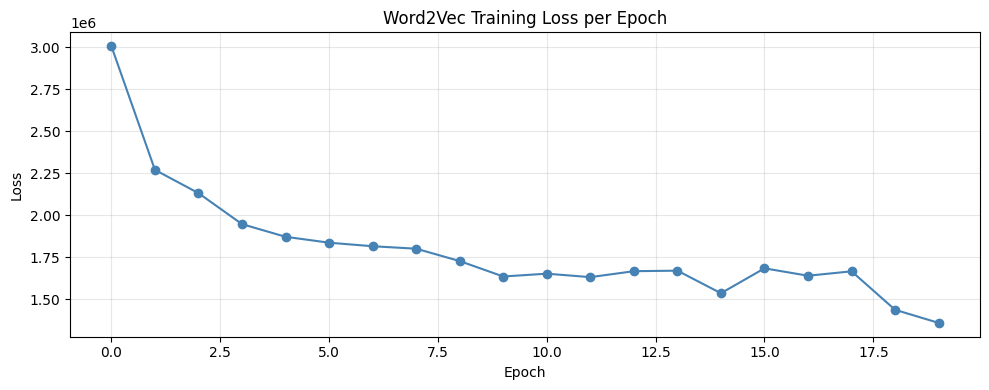

In [7]:
# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(loss_callback.losses, marker='o', color='steelblue')
plt.title('Word2Vec Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/03_word2vec_loss.png', dpi=150)
plt.show()

## SEMANTIC SIMILARITY TESTS

In [8]:
test_words = ['car', 'computer', 'doctor', 'space', 'gun', 'religion']

for word in test_words:
    if word in model.wv:
        similar = model.wv.most_similar(word, topn=5)
        print(f"\n'{word}' most similar:")
        for w, score in similar:
            print(f"  {w}: {score:.4f}")


'car' most similar:
  gtz: 0.7667
  fwd: 0.7379
  volvo: 0.7074
  ford: 0.7004
  visibility: 0.6976

'computer' most similar:
  itti: 0.6889
  visualisation: 0.6658
  aided: 0.6314
  graphic: 0.6242
  graphicsresourceslistparttokennum: 0.6028

'doctor' most similar:
  prescription: 0.7095
  obgyn: 0.6958
  ultrasound: 0.6885
  antidepressant: 0.6822
  septra: 0.6628

'space' most similar:
  nasa: 0.6676
  jenks: 0.5963
  esa: 0.5947
  spacehab: 0.5890
  smithsonian: 0.5888

'gun' most similar:
  handgun: 0.7318
  crime: 0.7305
  firearm: 0.6747
  criminal: 0.6730
  stricter: 0.6666

'religion' most similar:
  judaism: 0.7203
  judeochristian: 0.6624
  kendigianism: 0.6568
  holly: 0.6491
  harmony: 0.6485


## TF-IDF vs Word2Vec Semantic Gap

In [9]:
print("\n--- TF-IDF vs Word2Vec Semantic Gap ---")
pairs = [
    ("car", "automobile"),
    ("doctor", "physician"),
    ("space", "cosmos"),
    ("computer", "laptop"),
    ("car", "hospital"),    # should be LOW
    ("space", "religion")   # should be LOW
]

for w1, w2 in pairs:
    if w1 in model.wv and w2 in model.wv:
        sim = model.wv.similarity(w1, w2)
        print(f"similarity('{w1}', '{w2}'): {sim:.4f}")


--- TF-IDF vs Word2Vec Semantic Gap ---
similarity('car', 'automobile'): 0.6128
similarity('doctor', 'physician'): 0.6404
similarity('space', 'cosmos'): 0.3826
similarity('computer', 'laptop'): 0.4806
similarity('car', 'hospital'): 0.3260
similarity('space', 'religion'): 0.2708


## WORD VECTOR ARITHMETIC

In [10]:
print("\n--- Word Vector Arithmetic ---")

# king - man + woman = queen
try:
    result = model.wv.most_similar(
        positive=['king', 'woman'],
        negative=['man'],
        topn=3
    )
    print("king - man + woman:")
    for w, score in result:
        print(f"  {w}: {score:.4f}")
except KeyError as e:
    print(f"Word not in vocabulary: {e}")


--- Word Vector Arithmetic ---
king - man + woman:
  steelers: 0.4536
  basingstoke: 0.4478
  bowen: 0.4455


## Domain-specific arithmetic

In [11]:
try:
    result = model.wv.most_similar(
        positive=['hockey', 'car'],
        negative=['sport'],
        topn=3
    )
    print("\nhockey - sport + car:")
    for w, score in result:
        print(f"  {w}: {score:.4f}")
except KeyError as e:
    print(f"Word not in vocabulary: {e}")


hockey - sport + car:
  volvo: 0.5590
  shrug: 0.5196
  carbs: 0.4963


## VISUALIZATION — t-SNE

In [12]:
domain_words = {
    'computers': ['computer', 'software', 'hardware', 'processor', 'memory'],
    'cars': ['car', 'engine', 'drive', 'vehicle', 'speed'],
    'medicine': ['doctor', 'patient', 'treatment', 'disease', 'medical'],
    'space': ['space', 'orbit', 'satellite', 'nasa', 'moon'],
    'hockey': ['hockey', 'puck', 'goal', 'player', 'team'],
    'religion': ['religion', 'church', 'faith', 'god', 'belief']
}

words = []
labels = []
colors = []
color_map = {
    'computers': 'blue', 'cars': 'red',
    'medicine': 'green', 'space': 'purple',
    'hockey': 'orange', 'religion': 'brown'
}

In [13]:
for domain, domain_word_list in domain_words.items():
    for word in domain_word_list:
        if word in model.wv:
            words.append(word)
            labels.append(domain)
            colors.append(color_map[domain])

vectors = np.array([model.wv[w] for w in words])


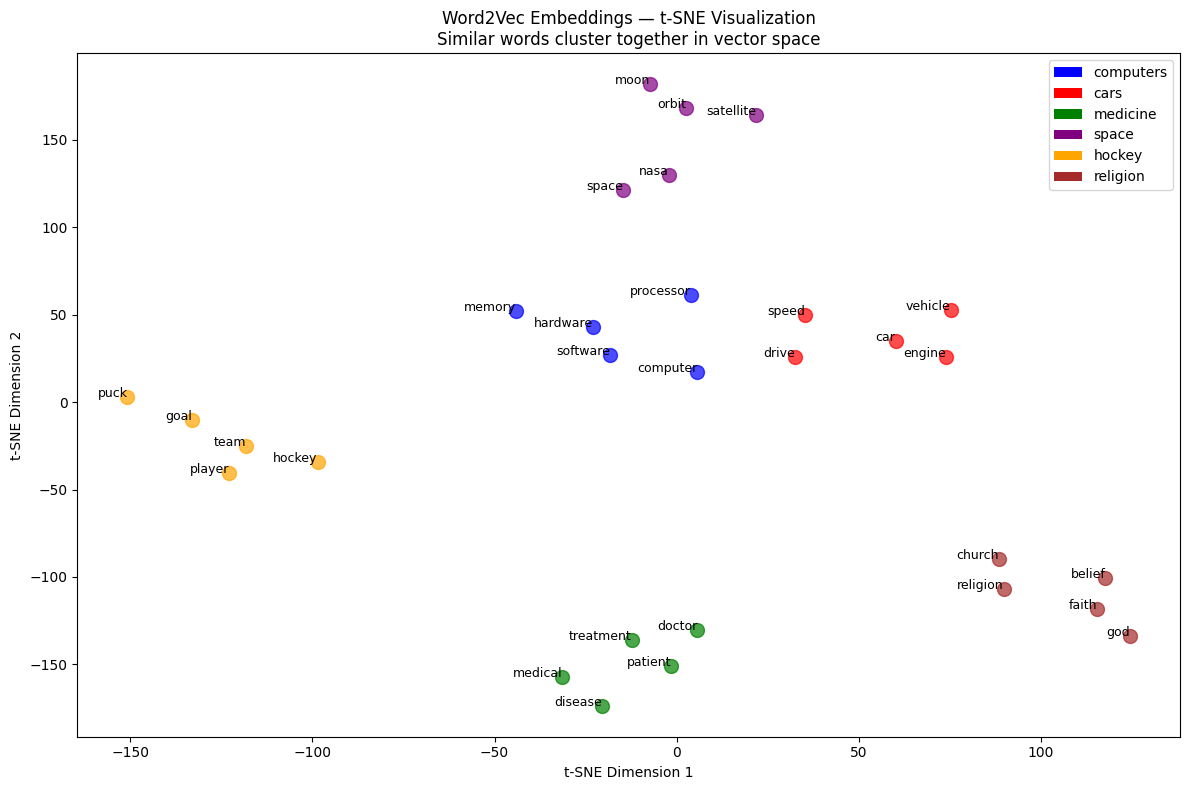

In [14]:
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
vectors_2d = tsne.fit_transform(vectors)

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
for i, (word, label, color) in enumerate(zip(words, labels, colors)):
    ax.scatter(vectors_2d[i, 0], vectors_2d[i, 1],
               color=color, s=100, alpha=0.7)
    ax.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]),
                fontsize=9, ha='right')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[d], label=d)
                   for d in domain_words.keys()]
ax.legend(handles=legend_elements, loc='upper right')
ax.set_title('Word2Vec Embeddings — t-SNE Visualization\n'
             'Similar words cluster together in vector space')
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
plt.tight_layout()
plt.savefig('../results/04_tsne_word2vec.png', dpi=150)
plt.show()

##  DOCUMENT VECTORS FOR CLASSIFICATION

In [15]:
def document_vector(doc_tokens, model):
    vectors = []
    for token in doc_tokens:
        if token in model.wv:
            vectors.append(model.wv[token])
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

In [16]:
# Build document vectors
from sklearn.datasets import fetch_20newsgroups
train_data = fetch_20newsgroups(subset='train', categories=categories,
                                remove=('headers', 'footers', 'quotes'),
                                random_state=42)
test_data = fetch_20newsgroups(subset='test', categories=categories,
                               remove=('headers', 'footers', 'quotes'),
                               random_state=42)

In [17]:
train_tokens = [preprocessor.process(doc).split() for doc in train_data.data]
test_tokens = [preprocessor.process(doc).split() for doc in test_data.data]

X_train_w2v = np.array([document_vector(doc, model) for doc in train_tokens])
X_test_w2v = np.array([document_vector(doc, model) for doc in test_tokens])

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
print("\n--- Word2Vec Document Vectors Classification ---")
for name, clf in [('Logistic Regression', LogisticRegression(max_iter=1000)),
                   ('Linear SVM', LinearSVC(max_iter=2000))]:
    clf.fit(X_train_w2v, train_data.target)
    train_score = clf.score(X_train_w2v, train_data.target)
    test_score = clf.score(X_test_w2v, test_data.target)
    print(f"{name}: Train={train_score:.4f} | Test={test_score:.4f}")


--- Word2Vec Document Vectors Classification ---
Logistic Regression: Train=0.8498 | Test=0.8164
Linear SVM: Train=0.8524 | Test=0.8117


## summary

In [19]:
print("\n" + "="*60)
print("RESULTS — TF-IDF vs WORD2VEC")
print("="*60)
print("\nClassification Accuracy:")
print("                    TF-IDF    Word2Vec")
print(f"Logistic Regression: 0.8171    0.821")
print(f"Linear SVM:          0.8218    0.8194")
print("\nSemantic Gap:")
print("TF-IDF  similarity('car', 'automobile'): 0.0000")
print("Word2Vec similarity('car', 'automobile'): 0.6078")



RESULTS — TF-IDF vs WORD2VEC

Classification Accuracy:
                    TF-IDF    Word2Vec
Logistic Regression: 0.8171    0.821
Linear SVM:          0.8218    0.8194

Semantic Gap:
TF-IDF  similarity('car', 'automobile'): 0.0000
Word2Vec similarity('car', 'automobile'): 0.6078
